# 06 — Director outputs (the curated few)

The presentation set, mirroring the northern `07_director_outputs` and the y2y trail
(`analyses/y2y/21_director_outputs`): only the maps that go on slides, each ONE asset function in
`wolverine_director` drawn through `director_plot.wide_map` — the y2y Act 1 **wide layout** (13.33 × 7.5 in
slide: the whole Y2Y frame at left, zoom insets A and B stacked at right, the key under A, the legend
under B; hillshade + Natural Earth basemap; PNG at 300 dpi + PDF). Colours and words come from
`corridors_mapstyle` (the §3a tokens); the frame draws at 600 m (one 300 dpi pixel of the frame panel is
~1.5 km). Existing PAs are the layout's grey layer, the refugia nodes the overlay (filled, outlined,
named in the insets), and the proposed IPCAs a second fill over the corridor land — so corridor land
inside PAs / IPCAs reads as already satisfied by the overlay (W11). Knobs: `wd.WIDE_STYLE` (then
`dp.STYLE`), `wd.STYLE`; `INSETS` = "examples" (A = the northernmost example link, B = the southernmost)
or "clusters" (the two densest node clusters).

The full record (every asset, tables, GIS, QA) is `04_tables_and_figures.ipynb`.

In [7]:
# ---- Setup: find the project root, import the shared engines ----------------
# This notebook lives in analyses/wolverine_refugia_connectivity/, below the repo root where
# config.py and the corridor engine modules sit. Same bootstrap as analyses/northern_connectivity/.
import sys, pathlib, json
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import numpy as np
import pandas as pd
import config
import corridors_prep as cp
import corridor_graph as cg
import corridors_core as cc
for _m in (config, cp, cg, cc):
    importlib.reload(_m)

KEY = "wolverine"
CFG = config.CORRIDORS[KEY]
HERE = ROOT / "analyses" / "wolverine_refugia_connectivity"

import matplotlib.pyplot as plt
import corridors_mapstyle as ms          # the §3a tokens: class + cost colours and words
import corridors_director as cd
import director_plot as dp               # the y2y Act 1 wide layout (one codebase with analyses/y2y/21 and the northern 07)
import wolverine_director as wd
for _m in (ms, cd, dp, wd):
    importlib.reload(_m)

import wolverine_postprocess as wp
importlib.reload(wp)
RUN = "v2_run001"                        # <-- the run to present
INSETS = "examples"                      # "examples" | "clusters"
wd.STYLE.update(wd.V25_STYLE)            # run spec v3 §1a: two acts, no hatched near-contiguous bands, complex labels carry [slivers]
R = wp.attach(cc.load_results(config.RESULTS_DIR / CFG["results_subdir"] / RUN))    # the v2.5 product from 05_v2_postprocess
P = wd.package(R)
acts = json.loads((R.run_dir / "postprocess" / "acts.json").read_text()) if (R.run_dir / "postprocess" / "acts.json").exists() else {}
if acts.get("break_moved"):              # the act check of 06: the Bow Valley rule, re-applied here
    wd.STYLE["act_breaks_lat"] = tuple(acts["act_breaks_lat"]); P = wd.package(R); P.act_note = acts.get("note", "")
F = wd.director_frame(P)                 # the run as a director_plot frame: 600 m grid, PAs grey, the refugia nodes as the overlay, the Y2Y window
dp.STYLE.update(wd.WIDE_STYLE)           # the wolverine knobs for the wide layout -- tweak dp.STYLE HERE, after this line, before drawing
plt.rcParams.update(dp.SPEC_RC)
OUT = P.out / "director_outputs"; OUT.mkdir(exist_ok=True)
print(f"frame {F.G.shape} @ {1000 / F.PX_PER_KM:.0f} m · window px {tuple(round(v) for v in F.WINDOW)} · insets {INSETS} → {OUT}")

v2_run001: results context loaded (170 edges, 44 branches, corridor 52,572 km²)
attached v2.5 product: 23 complexes, corridor links 37
wolverine package: classes -> only viable 0 · last affordable 4 · narrowing 13 · options 20 | geometric classes first (D25/D24): adjacent 130 (barrier between 0), width not assessable 0 | 23 nodes | 3 examples | H8 closed | already connected: 26 within existing PAs, 23 only with the proposed IPCAs (mode 'overlay')
frame (5519, 2143) @ 600 m · window px (-33, 2175, -33, 5552) · insets examples → /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs


## 01 — the movement-cost surface

What the land is made of on the surface the corridors were routed on ("O'Brien 2025, generic terrain rules
withheld"): the four movement-cost classes in the M0b magma swatches (1 intact · 10 roads and cuts · 100
converted · 1000 water, settlement and the retained barriers), existing PAs grey, proposed IPCAs filled, the
refugia nodes filled + outlined, postal codes on the frame, names + towns in the insets. The class shares
print for the slide's subtitle.

movement cost (withheld-terrain surface), share of the routable area: 1: 81.4% · 10: 10.0% · 100: 2.0% · 1000: 6.7%


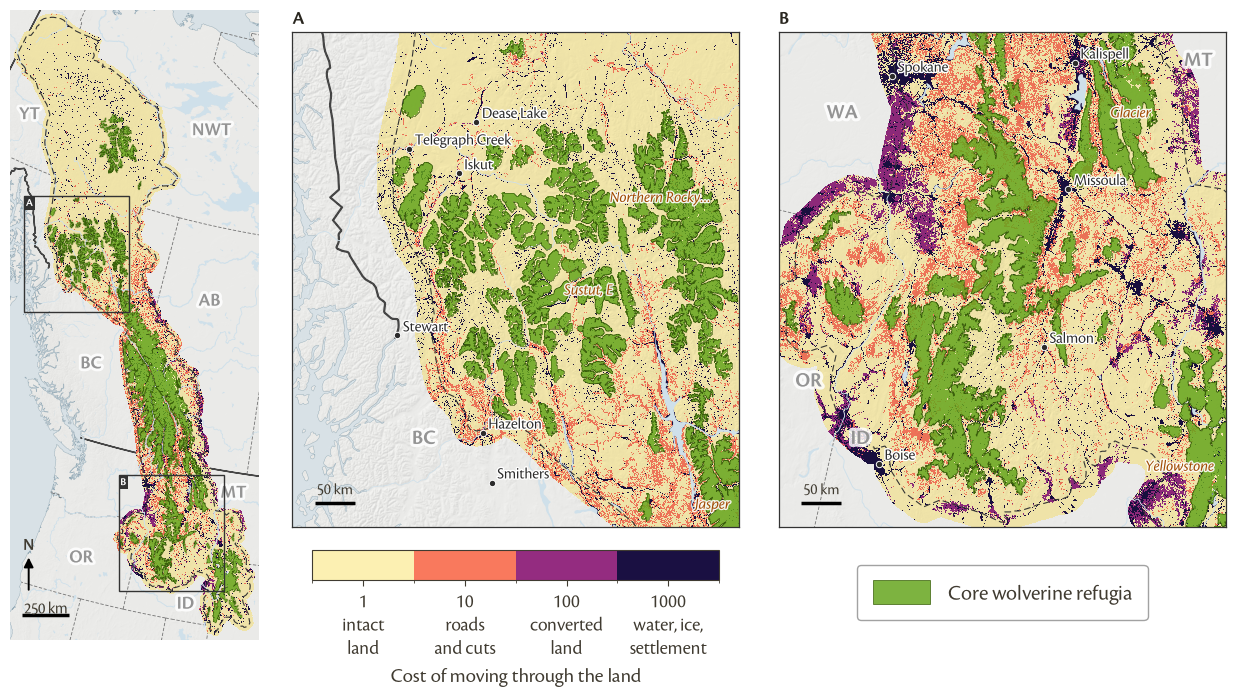

PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs/01_movement_cost.png')

In [8]:
wd.figure_cost_wide(P, OUT / "01_movement_cost.png", insets=INSETS)      # nodes = the complexes

## 02 — the refugia complexes and the corridors between them (v2.5, run spec v3 §1a)

Complex outlines with protection shading (fill alpha by the share inside existing PAs), the 40 corridor links by class in the
ramp slot, the tenth-percentile pinch marked on each corridor link, complex labels with [within-complex slivers] in the insets.
No hatched near-contiguous bands: that land is inside the complexes (D-W6).

corridor links per class: securing 20 · squeezed 13 · edge 4 · both 0 | 23 complexes | already connected: 26 within existing PAs, 23 once the proposed IPCAs are realized | band = about 4.1 km of extra travel on open ground


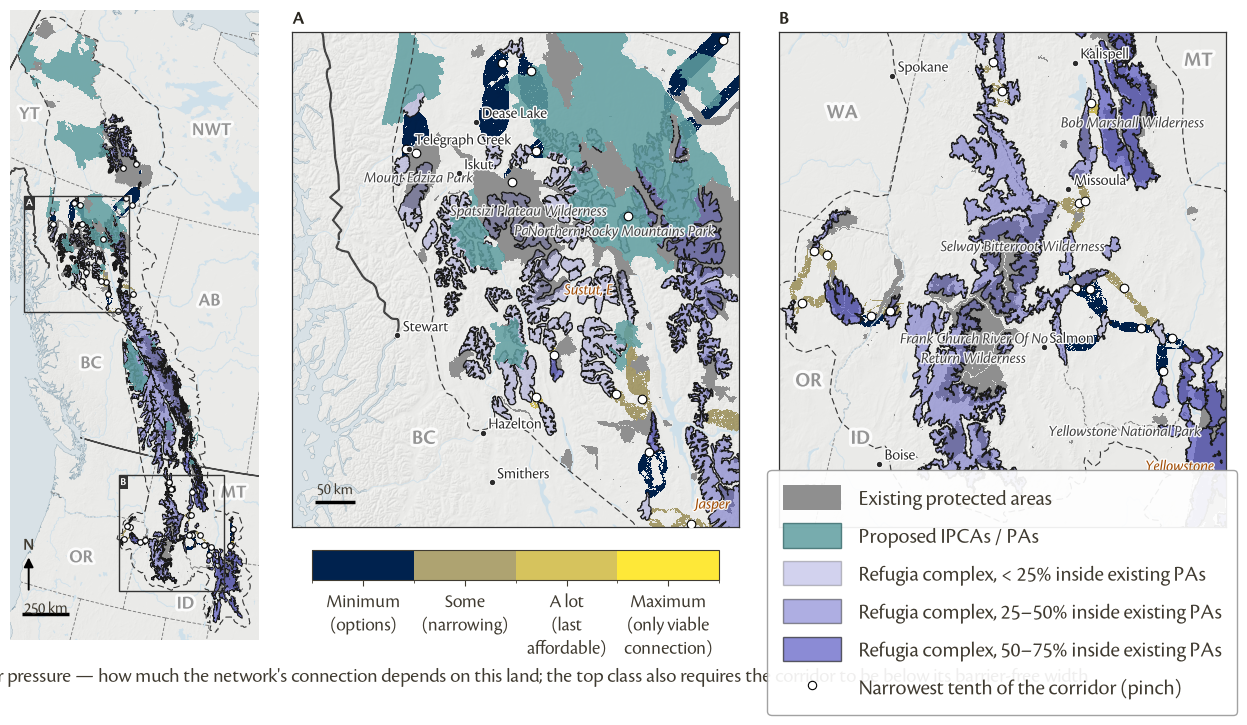

PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs/02_complexes_and_corridors.png')

In [9]:
wd.figure_network_wide(P, OUT / "02_complexes_and_corridors.png", insets=INSETS)

## 03 — the route options

The deck's numbered examples (up to four, the automatic rule: the link under the most pressure in each act, then a
"room to choose" link; or your pins in `wd.EXAMPLE_PICKS`), numbered north → south. Each option = one link's full
corridor band, filled in its number's colour from the y2y cluster palette over the pressure classes, numbered at the
band's median cell; the PA / IPCA / node fills sit on top, as on the northern 07 · 03. Inset A holds options 1–2 and B
holds 3–4 (one each when a pair does not fit one window). The legend entry is the y2y cluster swatch, "Route options".

route options: 1 #D7263D at px (602, 2383) (nw) · 2 #1E90FF at px (1588, 4250) (nw) · 3 #E040A0 at px (1560, 4738) (nw)


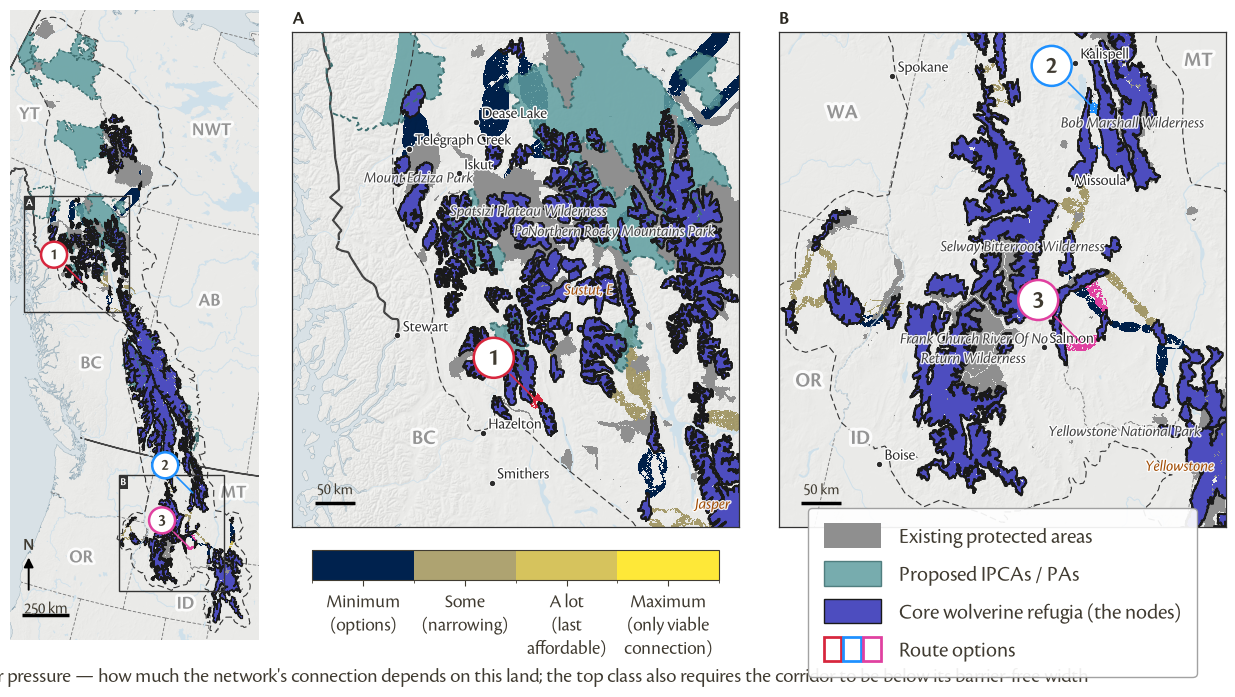

PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs/03_route_options.png')

In [10]:
wd.figure_options_wide(P, OUT / "03_route_options.png", insets=INSETS)

## 04 — the route options: star plots + locators

The y2y Act 1 stars (`director_plot.star_grid`, one star per option in its colour): each axis = the option's mean
PERCENTILE of a theme against the Y2Y-wide allocatable landscape (`director_core.block_percentiles`; dashed ring 0.5 =
the typical unprotected cell; fractional 300 m → 1 km cover). Under them, the two inset windows A and B as locator
panels on the star grid's geometry. The first call computes the y2y layers' percentiles (~1–2 min) and caches them on `P`.

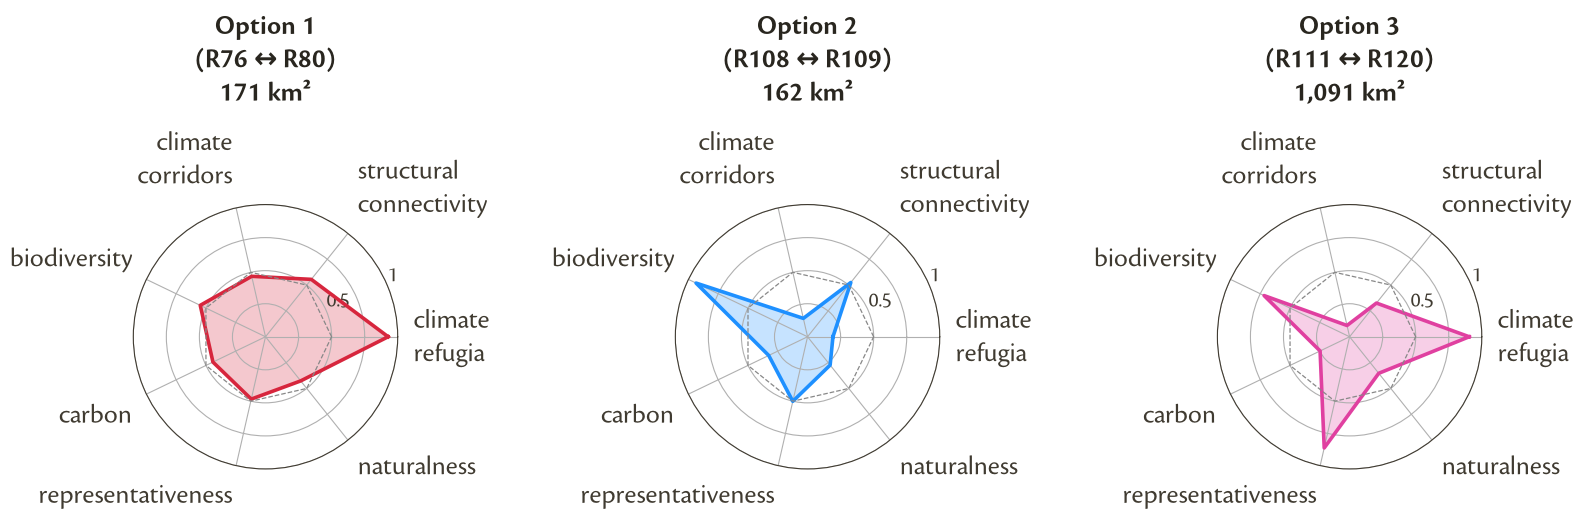

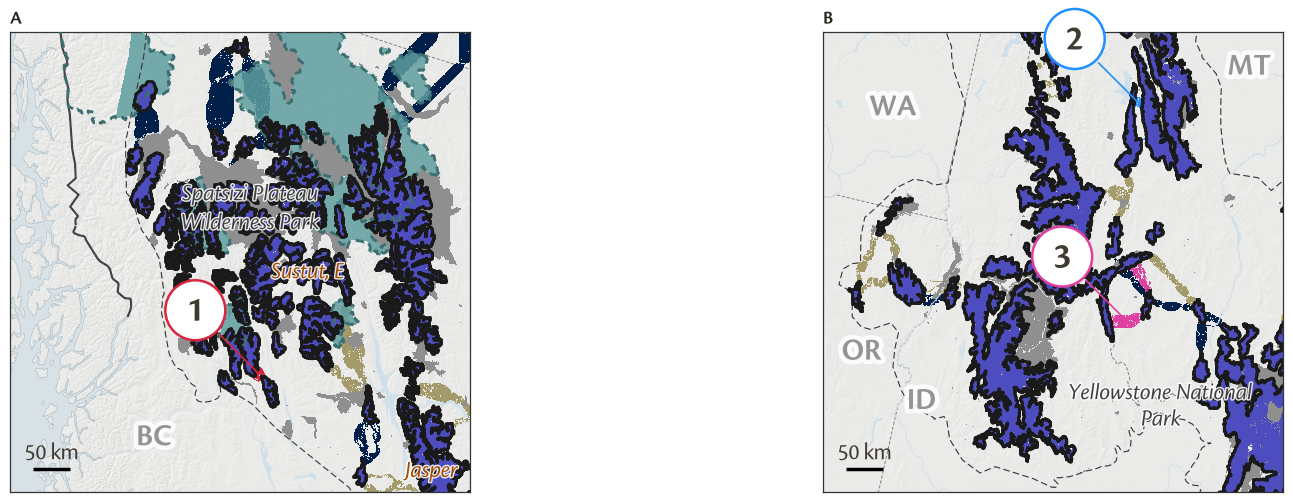

PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs/04b_route_option_locators.png')

In [11]:
wd.option_stars(P, OUT / "04_route_option_stars.png")
wd.option_locators(P, OUT / "04b_route_option_locators.png", insets=INSETS, panel_px=620)   # + each panel as its own file (_A, _B)

## 05 — the route options: consequences

The y2y consequences table (`director_plot.consequences_table`, transposed, per-row red → blue fills over the option
columns): mean raw value in the option's land ÷ mean over Y2Y-wide allocatable land, per theme ("2.3×" = 2.3 times the
average unprotected cell), columns = the options then two reference areas — Banff National Park (existing PA) and
Dene Kʼéh Kusān (proposed IPCA), the y2y tables' rule (`wd.CONSEQ_REFERENCE`). Rows also to
`director_package/tables/route_option_consequences.csv`.

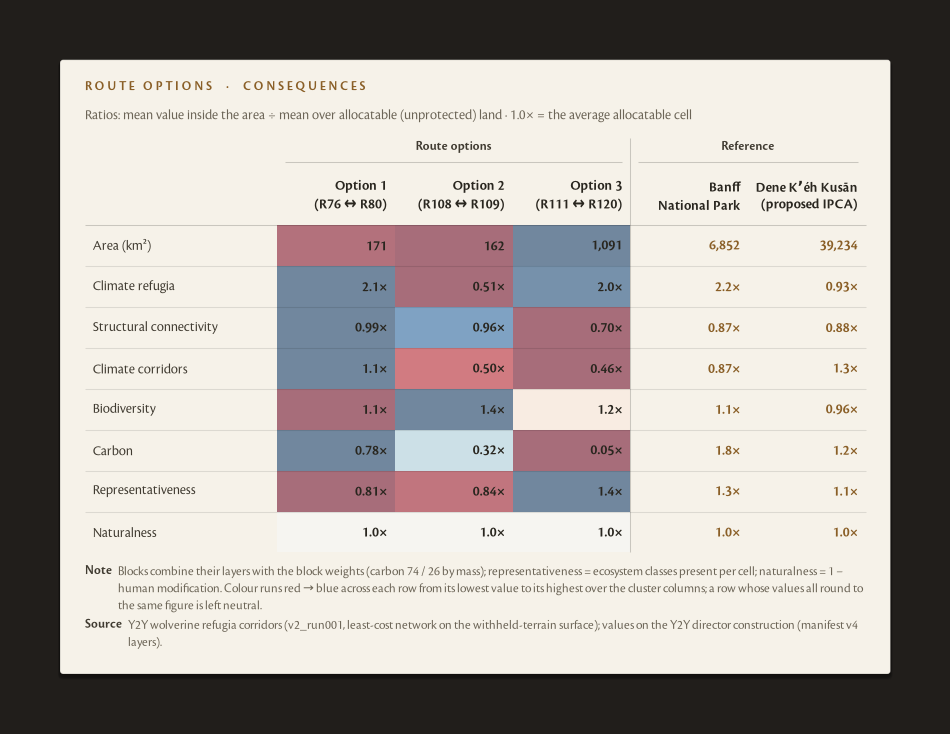

,kind,number,name,area_km2,pct_core habitat,pct_structural connectivity,pct_climate corridors,pct_biodiversity,pct_carbon,pct_representativeness,pct_naturalness,ratio_core habitat,ratio_structural connectivity,ratio_climate corridors,ratio_biodiversity,ratio_carbon,ratio_representativeness,ratio_naturalness
0,option,1,R76 ↔ R80,170.91,0.927676,0.555354,0.469024,0.547767,0.441206,0.483718,0.426984,2.080143,0.989780,1.081932,1.052175,0.783994,0.809109,1.003289
1,option,2,R108 ↔ R109,161.82,0.192209,0.524897,0.142646,0.936041,0.325978,0.500933,0.274011,0.514144,0.958287,0.499435,1.429096,0.317148,0.835699,1.016138
2,option,3,R111 ↔ R120,1091.07,0.904782,0.325894,0.087539,0.717825,0.247712,0.862472,0.353558,1.981608,0.696449,0.456287,1.205337,0.053658,1.352883,1.021301
3,reference,,Banff National Park,6852.06,0.898979,0.335816,0.367295,0.570596,0.666334,0.784582,0.604589,2.228842,0.865279,0.873242,1.053504,1.818549,1.266351,1.028521
4,reference,,Dene Kʼéh Kusān (proposed IPCA),39234.06,0.607513,0.463628,0.699714,0.484700,0.591726,0.750564,0.662825,0.933032,0.879385,1.274871,0.964543,1.174229,1.122385,1.046620


In [12]:
wd.option_consequences(P, OUT / "05_route_option_consequences.png")